In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
files = {
    'GE': 'postagging_genoese_ORDINATO.csv',
    'IT': 'postagging_italian.csv',
    'FR': 'postagging_french.csv',
    'PT': 'postagging_portuguese.csv',
}

dfs = []
for lang, file in files.items():
	df = pd.read_csv(file)
	rename_cols = {'POS_GROUPED': f'POS_{lang}'}
	df = df.rename(columns=rename_cols)
	df = df[[c for c in df.columns if c in ['SENTENCE', 'TEXT', f'POS_{lang}']]]
	df['word_instance'] = df.groupby('TEXT').cumcount()

	if lang == 'GE':
		df['original_index'] = range(len(df))  # aggiungi una colonna per mantenere l'ordine originale
	else:
		df = df.drop(columns=['SENTENCE'])  # rimuovi la colonna SENTENCE per gli altri file

	dfs.append(df)
    
merged_df = dfs[0]
for df in dfs[1:]:
	merged_df = pd.merge(merged_df, df, on=['TEXT', 'word_instance'], how='outer')
drop_cols = [cols for cols in merged_df.columns if '_drop' in cols]
merged_df = merged_df.drop(columns=drop_cols)

if 'original_index' in merged_df.columns:
    merged_df = merged_df.sort_values('original_index')
    merged_df = merged_df.drop(columns=['original_index'])

merged_df = merged_df.drop(columns=['word_instance']) # rimozione colonna tecnica
for col in merged_df.columns:
	if col.startswith('POS_'):
		merged_df[col] = merged_df[col].fillna('NA')
merged_df.to_csv('postagging_merged.csv', index=False)
merged_df.head()

,SENTENCE,TEXT,POS_GE,POS_IT,POS_FR,POS_PT
803,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",O,PRON,NOUN,NOUN,PRON
1018,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Zouhaur,NOUN,NOUN,NOUN,NOUN
541,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",Atif,NOUN,NOUN,NOUN,NOUN
3,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",",",PUNCT,PUNCT,PUNCT,PUNCT
3248,"O Zouhaur Atif, o zoeno arrestou pe avei ammas...",o,PRON,FUNC,FUNC,PRON


In [3]:
def evaluation(df):
	IT_correct = 0
	FR_correct = 0
	PT_correct = 0

	IT_null = 0
	FR_null = 0
	PT_null = 0

	for _, row in df.iterrows():

		if row['POS_GE'] == row['POS_IT']:
			IT_correct += 1
		if row['POS_GE'] == row['POS_FR']:
			FR_correct += 1
		if row['POS_GE'] == row['POS_PT']:
			PT_correct += 1

		if row['POS_IT'] == 'NA':
			IT_null += 1
		if row['POS_FR'] == 'NA':
			FR_null += 1
		if row['POS_PT'] == 'NA':
			PT_null += 1

	return IT_correct, FR_correct, PT_correct, IT_null, FR_null, PT_null

In [4]:
IT_correct, FR_correct, PT_correct, IT_null, FR_null, PT_null = evaluation(merged_df)
total = len(merged_df)

perc_correct_IT = IT_correct / total * 100
perc_correct_FR = FR_correct / total * 100
perc_correct_PT = PT_correct / total * 100
perc_null_IT = IT_null / total * 100
perc_null_FR = FR_null / total * 100
perc_null_PT = PT_null / total * 100

print(f"IT: {perc_correct_IT:.2f}% correct ({IT_correct}/{total}), {perc_null_IT:.2f}% null ({IT_null}/{total})")
print(f"FR: {perc_correct_FR:.2f}% correct ({FR_correct}/{total}), {perc_null_FR:.2f}% null ({FR_null}/{total})")
print(f"PT: {perc_correct_PT:.2f}% correct ({PT_correct}/{total}), {perc_null_PT:.2f}% null ({PT_null}/{total})")

IT: 49.11% correct (2288/4659), 18.52% null (863/4659)
FR: 39.36% correct (1834/4659), 19.32% null (900/4659)
PT: 52.44% correct (2443/4659), 28.25% null (1316/4659)


In [5]:
def countPOS(df):
	NOUN, VERB, ADJ, PRON, ADV, PUNCT, FUNC, OTHER = 0, 0, 0, 0, 0, 0, 0, 0
	for _, row in df.iterrows():
		pos = row['POS_GE']
		if pos == 'NOUN':
			NOUN += 1
		elif pos == 'VERB':
			VERB += 1
		elif pos == 'ADJ':
			ADJ += 1
		elif pos == 'PRON':
			PRON += 1
		elif pos == 'ADV':
			ADV += 1
		elif pos == 'PUNCT':
			PUNCT += 1
		elif pos == 'FUNC':
			FUNC += 1
		elif pos == 'OTHER':
			OTHER += 1
	return NOUN, VERB, ADJ, PRON, ADV, PUNCT, FUNC, OTHER

NOUN, VERB, ADJ, PRON, ADV, PUNCT, FUNC, OTHER = countPOS(merged_df)

In [6]:
def modified_evaluation_IT(df): # which are the best recognized tags, without considering null values
	NOUN_correct = 0
	VERB_correct = 0
	ADJ_correct = 0
	PRON_correct = 0
	ADV_correct = 0
	PUNCT_correct = 0
	FUNC_correct = 0
	OTHER_correct = 0

	for _, row in df.iterrows():
		if row['POS_GE'] == row['POS_IT']:
			if row['POS_GE'] == 'NOUN':
				NOUN_correct += 1
			elif row['POS_GE'] == 'VERB':
				VERB_correct += 1
			elif row['POS_GE'] == 'ADJ':
				ADJ_correct += 1
			elif row['POS_GE'] == 'PRON':
				PRON_correct += 1
			elif row['POS_GE'] == 'ADV':
				ADV_correct += 1
			elif row['POS_GE'] == 'PUNCT':
				PUNCT_correct += 1
			elif row['POS_GE'] == 'FUNC':
				FUNC_correct += 1
			elif row['POS_GE'] == 'OTHER':
				OTHER_correct += 1

	return NOUN_correct, VERB_correct, ADJ_correct, PRON_correct, ADV_correct, PUNCT_correct, FUNC_correct, OTHER_correct

NOUN_correct_IT, VERB_correct_IT, ADJ_correct_IT, PRON_correct_IT, ADV_correct_IT, PUNCT_correct_IT, FUNC_correct_IT, OTHER_correct_IT = modified_evaluation_IT(merged_df)

In [7]:
def modified_evaluation_FR(df): # which are the best recognized tags, without considering null values
	NOUN_correct = 0
	VERB_correct = 0
	ADJ_correct = 0
	PRON_correct = 0
	ADV_correct = 0
	PUNCT_correct = 0
	FUNC_correct = 0
	OTHER_correct = 0

	for _, row in df.iterrows():
		if row['POS_GE'] == row['POS_FR']:
			if row['POS_GE'] == 'NOUN':
				NOUN_correct += 1
			elif row['POS_GE'] == 'VERB':
				VERB_correct += 1
			elif row['POS_GE'] == 'ADJ':
				ADJ_correct += 1
			elif row['POS_GE'] == 'PRON':
				PRON_correct += 1
			elif row['POS_GE'] == 'ADV':
				ADV_correct += 1
			elif row['POS_GE'] == 'PUNCT':
				PUNCT_correct += 1
			elif row['POS_GE'] == 'FUNC':
				FUNC_correct += 1
			elif row['POS_GE'] == 'OTHER':
				OTHER_correct += 1

	return NOUN_correct, VERB_correct, ADJ_correct, PRON_correct, ADV_correct, PUNCT_correct, FUNC_correct, OTHER_correct

NOUN_correct_FR, VERB_correct_FR, ADJ_correct_FR, PRON_correct_FR, ADV_correct_FR, PUNCT_correct_FR, FUNC_correct_FR, OTHER_correct_FR = modified_evaluation_FR(merged_df)

In [8]:
def modified_evaluation_PT(df): # which are the best recognized tags, without considering null values
	NOUN_correct = 0
	VERB_correct = 0
	ADJ_correct = 0
	PRON_correct = 0
	ADV_correct = 0
	PUNCT_correct = 0
	FUNC_correct = 0
	OTHER_correct = 0

	for _, row in df.iterrows():
		if row['POS_GE'] == row['POS_PT']:
			if row['POS_GE'] == 'NOUN':
				NOUN_correct += 1
			elif row['POS_GE'] == 'VERB':
				VERB_correct += 1
			elif row['POS_GE'] == 'ADJ':
				ADJ_correct += 1
			elif row['POS_GE'] == 'PRON':
				PRON_correct += 1
			elif row['POS_GE'] == 'ADV':
				ADV_correct += 1
			elif row['POS_GE'] == 'PUNCT':
				PUNCT_correct += 1
			elif row['POS_GE'] == 'FUNC':
				FUNC_correct += 1
			elif row['POS_GE'] == 'OTHER':
				OTHER_correct += 1

	return NOUN_correct, VERB_correct, ADJ_correct, PRON_correct, ADV_correct, PUNCT_correct, FUNC_correct, OTHER_correct

NOUN_correct_PT, VERB_correct_PT, ADJ_correct_PT, PRON_correct_PT, ADV_correct_PT, PUNCT_correct_PT, FUNC_correct_PT, OTHER_correct_PT = modified_evaluation_PT(merged_df)

In [9]:
print(f"IT: NOUN {NOUN_correct_IT}/{NOUN}, VERB {VERB_correct_IT}/{VERB}, ADJ {ADJ_correct_IT}/{ADJ}, PRON {PRON_correct_IT}/{PRON}, ADV {ADV_correct_IT}/{ADV}, PUNCT {PUNCT_correct_IT}/{PUNCT}, FUNC {FUNC_correct_IT}/{FUNC}, OTHER {OTHER_correct_IT}/{OTHER}")
print(f"FR: NOUN {NOUN_correct_FR}/{NOUN}, VERB {VERB_correct_FR}/{VERB}, ADJ {ADJ_correct_FR}/{ADJ}, PRON {PRON_correct_FR}/{PRON}, ADV {ADV_correct_FR}/{ADV}, PUNCT {PUNCT_correct_FR}/{PUNCT}, FUNC {FUNC_correct_FR}/{FUNC}, OTHER {OTHER_correct_FR}/{OTHER}")
print(f"PT: NOUN {NOUN_correct_PT}/{NOUN}, VERB {VERB_correct_PT}/{VERB}, ADJ {ADJ_correct_PT}/{ADJ}, PRON {PRON_correct_PT}/{PRON}, ADV {ADV_correct_PT}/{ADV}, PUNCT {PUNCT_correct_PT}/{PUNCT}, FUNC {FUNC_correct_PT}/{FUNC}, OTHER {OTHER_correct_PT}/{OTHER}")

IT: NOUN 766/912, VERB 162/498, ADJ 133/243, PRON 103/669, ADV 38/146, PUNCT 409/666, FUNC 420/698, OTHER 0/17
FR: NOUN 601/912, VERB 97/498, ADJ 116/243, PRON 79/669, ADV 9/146, PUNCT 386/666, FUNC 231/698, OTHER 4/17
PT: NOUN 645/912, VERB 139/498, ADJ 82/243, PRON 241/669, ADV 11/146, PUNCT 406/666, FUNC 362/698, OTHER 0/17


In [10]:
# percentages
perc_correct_NOUN_IT = NOUN_correct_IT / NOUN * 100
perc_correct_VERB_IT = VERB_correct_IT / VERB * 100
perc_correct_ADJ_IT = ADJ_correct_IT / ADJ * 100
perc_correct_PRON_IT = PRON_correct_IT / PRON * 100
perc_correct_ADV_IT = ADV_correct_IT / ADV * 100
perc_correct_PUNCT_IT = PUNCT_correct_IT / PUNCT * 100
perc_correct_FUNC_IT = FUNC_correct_IT / FUNC * 100
perc_correct_OTHER_IT = OTHER_correct_IT / OTHER * 100

perc_correct_NOUN_FR = NOUN_correct_FR / NOUN * 100
perc_correct_VERB_FR = VERB_correct_FR / VERB * 100
perc_correct_ADJ_FR = ADJ_correct_FR / ADJ * 100
perc_correct_PRON_FR = PRON_correct_FR / PRON * 100
perc_correct_ADV_FR = ADV_correct_FR / ADV * 100
perc_correct_PUNCT_FR = PUNCT_correct_FR / PUNCT * 100
perc_correct_FUNC_FR = FUNC_correct_FR / FUNC * 100
perc_correct_OTHER_FR = OTHER_correct_FR / OTHER * 100

perc_correct_NOUN_PT = NOUN_correct_PT / NOUN * 100
perc_correct_VERB_PT = VERB_correct_PT / VERB * 100
perc_correct_ADJ_PT = ADJ_correct_PT / ADJ * 100
perc_correct_PRON_PT = PRON_correct_PT / PRON * 100
perc_correct_ADV_PT = ADV_correct_PT / ADV * 100
perc_correct_PUNCT_PT = PUNCT_correct_PT / PUNCT * 100
perc_correct_FUNC_PT = FUNC_correct_PT / FUNC * 100
perc_correct_OTHER_PT = OTHER_correct_PT / OTHER * 100

print(f"IT: NOUN {perc_correct_NOUN_IT:.2f}%, VERB {perc_correct_VERB_IT:.2f}%, ADJ {perc_correct_ADJ_IT:.2f}%, PRON {perc_correct_PRON_IT:.2f}%, ADV {perc_correct_ADV_IT:.2f}%, PUNCT {perc_correct_PUNCT_IT:.2f}%, FUNC {perc_correct_FUNC_IT:.2f}%, OTHER {perc_correct_OTHER_IT:.2f}%")
print(f"FR: NOUN {perc_correct_NOUN_FR:.2f}%, VERB {perc_correct_VERB_FR:.2f}%, ADJ {perc_correct_ADJ_FR:.2f}%, PRON {perc_correct_PRON_FR:.2f}%, ADV {perc_correct_ADV_FR:.2f}%, PUNCT {perc_correct_PUNCT_FR:.2f}%, FUNC {perc_correct_FUNC_FR:.2f}%, OTHER {perc_correct_OTHER_FR:.2f}%")
print(f"PT: NOUN {perc_correct_NOUN_PT:.2f}%, VERB {perc_correct_VERB_PT:.2f}%, ADJ {perc_correct_ADJ_PT:.2f}%, PRON {perc_correct_PRON_PT:.2f}%, ADV {perc_correct_ADV_PT:.2f}%, PUNCT {perc_correct_PUNCT_PT:.2f}%, FUNC {perc_correct_FUNC_PT:.2f}%, OTHER {perc_correct_OTHER_PT:.2f}%")

IT: NOUN 83.99%, VERB 32.53%, ADJ 54.73%, PRON 15.40%, ADV 26.03%, PUNCT 61.41%, FUNC 60.17%, OTHER 0.00%
FR: NOUN 65.90%, VERB 19.48%, ADJ 47.74%, PRON 11.81%, ADV 6.16%, PUNCT 57.96%, FUNC 33.09%, OTHER 23.53%
PT: NOUN 70.72%, VERB 27.91%, ADJ 33.74%, PRON 36.02%, ADV 7.53%, PUNCT 60.96%, FUNC 51.86%, OTHER 0.00%


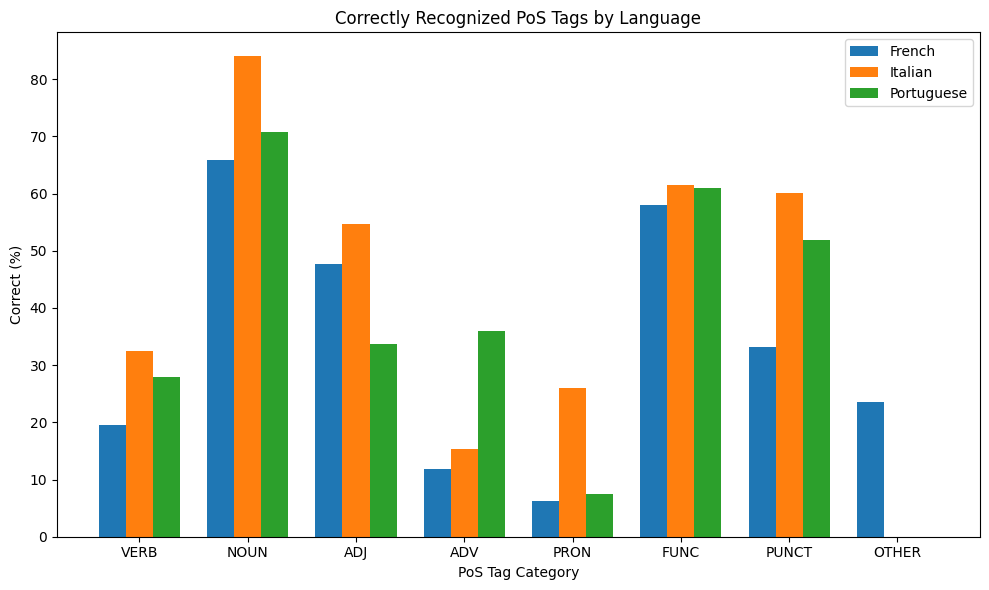

In [11]:
labels = ['VERB', 'NOUN', 'ADJ', 'ADV', 'PRON',  'FUNC', 'PUNCT', 'OTHER']
x = list(range(len(labels)))
width = 0.25

it_vals = [perc_correct_VERB_IT, perc_correct_NOUN_IT, perc_correct_ADJ_IT, perc_correct_PRON_IT,
		   perc_correct_ADV_IT, perc_correct_PUNCT_IT, perc_correct_FUNC_IT, perc_correct_OTHER_IT]
fr_vals = [perc_correct_VERB_FR, perc_correct_NOUN_FR, perc_correct_ADJ_FR, perc_correct_PRON_FR,
		   perc_correct_ADV_FR, perc_correct_PUNCT_FR, perc_correct_FUNC_FR, perc_correct_OTHER_FR]
pt_vals = [perc_correct_VERB_PT, perc_correct_NOUN_PT, perc_correct_ADJ_PT, perc_correct_PRON_PT,
		   perc_correct_ADV_PT, perc_correct_PUNCT_PT, perc_correct_FUNC_PT, perc_correct_OTHER_PT]

plt.figure(figsize=(10, 6))
plt.bar([i - width for i in x], fr_vals, width=width, label='French')
plt.bar(x, it_vals, width=width, label='Italian')
plt.bar([i + width for i in x], pt_vals, width=width, label='Portuguese')

plt.xticks(x, labels)
plt.xlabel('PoS Tag Category')
plt.ylabel('Correct (%)')
plt.title('Correctly Recognized PoS Tags by Language')
plt.legend()
plt.tight_layout()